# Exercise 1 — Logistic Regression

## Part A: Understanding Logistic Regression

Imagine we want to predict whether a student will pass an exam.

For each student, we know:

* the number of study hours
* whether the student passed or failed

Our goal is to predict: `pass (1) or fail (0)`

Unlike linear regression, logistic regression predicts a probability between 0 and 1.

### Logistic Regression Model

The model is:

`z = weight × x + bias`

Then we apply the sigmoid function:

`p = 1 / (1 + e^(-z))`

Where:

* x = input feature (study hours)
* weight = importance of the feature
* bias = shifts the curve
* p = probability of passing

### Decision Rule

After computing the probability:

`if p > 0.5 → predict PASS

else → predict FAIL`

Your Task

Change the values of: `weight` and `bias` as in previous exercises.

until the sigmoid curve separates the two classes as well as possible.

Try to understand:

* what the weight changes
* what the bias changes
* where the decision boundary appears

### Sample Student Data

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# x = study hours
x = np.array([0,1,2,3,4,5,6,7,8,9])

# y = fail(0) or pass(1)
y = np.array([0,0,0,0,0,1,1,1,1,1])

In [9]:
weight = 1.5
bias = -7

### Logistic Regression Predictions

In [10]:
# Linear part
z = weight * x + bias

# Sigmoid
p = 1 / (1 + np.exp(-z))

# Predicted classes
y_pred = (p > 0.5).astype(int)

### Plot the model

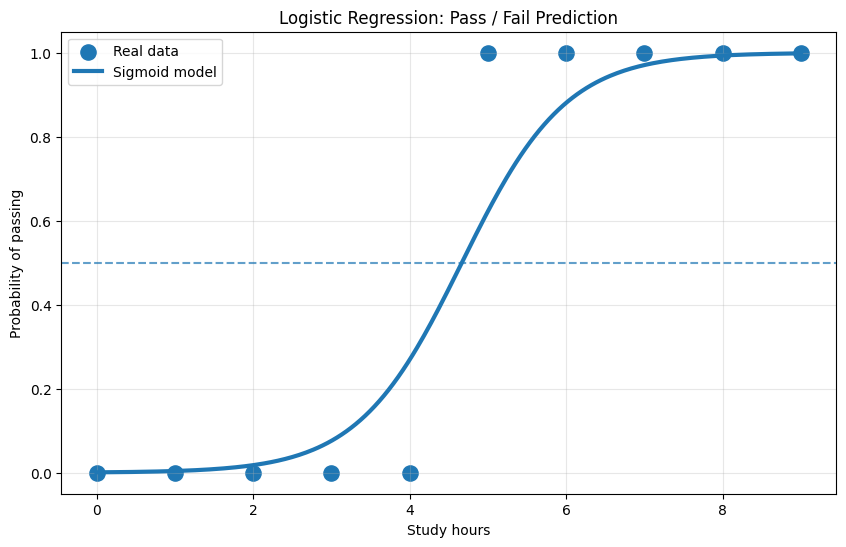

In [11]:
plt.figure(figsize=(10,6))

# Real data
plt.scatter(x, y, s=120, label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(0, 9, 300)
z_curve = weight * x_curve + bias
p_curve = 1 / (1 + np.exp(-z_curve))

plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")

# Decision threshold
plt.axhline(0.5, linestyle="--", alpha=0.7)

plt.xlabel("Study hours")
plt.ylabel("Probability of passing")
plt.title("Logistic Regression: Pass / Fail Prediction")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

Questions

1. What does the weight control?
- Weight controls the steepness of the sigmoid curve and how much study hours matter
2. What does the bias control?
- Weight controls the steepness of the sigmoid curve and how much study hours matter
3. What happens when the sigmoid becomes steeper?
- A steep sigmoid means even a small increase in study hours flips the prediction dramatically.
4. Where is the decision boundary?
- The decision boundary is where p = 0.5, which is the dashed horizontal line in the plot
5. Which students are difficult to classify?
- Students at ~6–8 hours are the hardest to classify. In the scatter plot, these are the points sitting closest to the dashed line.
6. Why is logistic regression better than linear regression here?
- If you used linear regression here, a student with 0 hours might get a prediction of -0.7 and one with 9 hours might get 1.6 — neither is a valid probability. The sigmoid squashes everything into [0, 1], making predictions interpretable as probabilities.

## Part B — Use a Real Dataset

Now repeat the same process using a real dataset.

Choose:

- one numerical column as `x`
- one binary column as `y`

Below are beginner-friendly datasets you can use.

| Dataset | Link | Example `x` | Example `y` | Task |
|---|---|---|---|---|
| Titanic | [Open dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv) | `Age`, `Fare` | `Survived` | Predict survival |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | `mean radius`, `mean texture` | `target` | Benign vs malignant |
| Heart Disease | [Open dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) | `cholesterol`, `age` | `disease` | Predict heart disease |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | `bill_length_mm`, `body_mass_g` | species converted to binary | Classify penguin species |
| Student Performance | [Open dataset](https://archive.ics.uci.edu/dataset/320/student+performance) | `studytime`, `absences` | pass/fail from final grade | Predict pass/fail |
| SMS Spam | [Open dataset](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) | message length, number of keywords | spam / ham | Spam detection |

### Suggested choice 

Use the **Titanic dataset** first:

In [12]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Your Real-Data Task

1. Load the dataset.
2. Display the first rows with df.head().
3. Choose one feature x.
4. Choose one binary target y.
5. Plot the data.
6. Try different values of weight and bias.
7. Observe how the sigmoid changes.
8. Compare your intuition with Python’s logistic regression model.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [15]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [16]:
df_clean = df[["Age", "Survived"]].dropna()

x = df_clean["Age"].values
y = df_clean["Survived"].values

print(f"Passengers with valid Age: {len(x)}")
print(f"Survived: {y.sum()}  |  Died: {(y==0).sum()}")

Passengers with valid Age: 714
Survived: 290  |  Died: 424


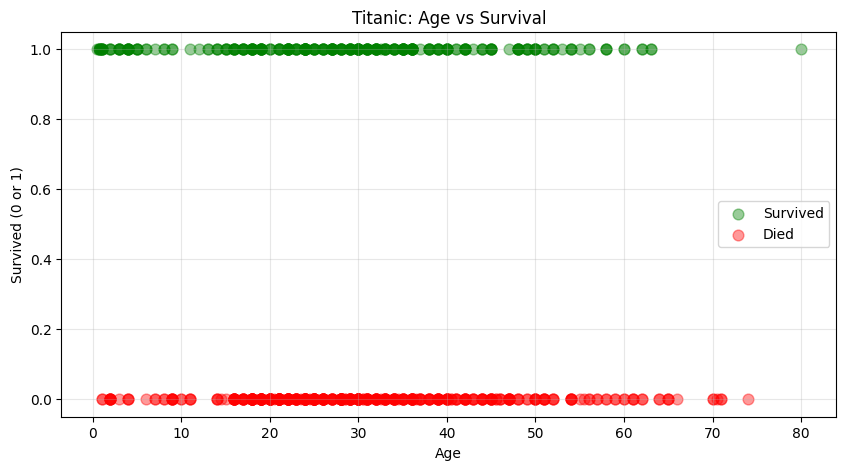

In [17]:
plt.figure(figsize=(10, 5))
plt.scatter(x[y == 1], y[y == 1], color="green", label="Survived", alpha=0.4, s=60)
plt.scatter(x[y == 0], y[y == 0], color="red",   label="Died",     alpha=0.4, s=60)
plt.xlabel("Age")
plt.ylabel("Survived (0 or 1)")
plt.title("Titanic: Age vs Survival")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Decision boundary at Age = 50.0


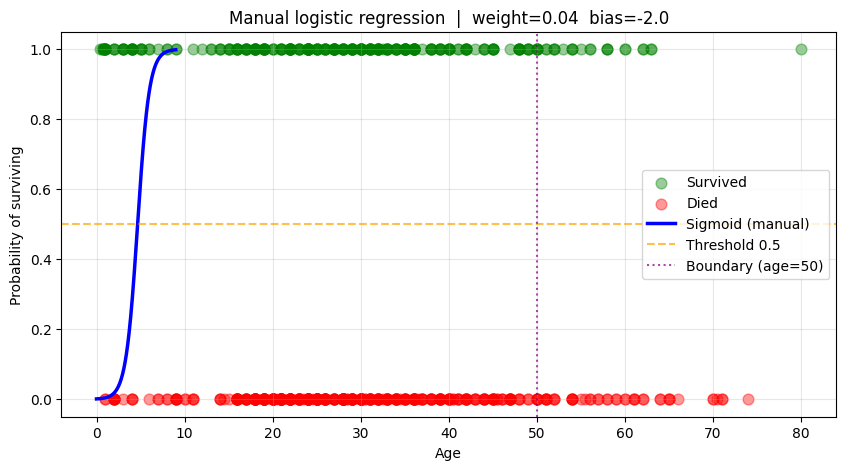

In [19]:
weight = 0.04
bias   = -2.0

boundary = -bias / weight
print(f"Decision boundary at Age = {boundary:.1f}")

plt.figure(figsize=(10, 5))
plt.scatter(x[y == 1], y[y == 1], color="green", label="Survived", alpha=0.4, s=60)
plt.scatter(x[y == 0], y[y == 0], color="red",   label="Died",     alpha=0.4, s=60)
plt.plot(x_curve, p_curve, color="blue", linewidth=2.5, label="Sigmoid (manual)")
plt.axhline(0.5, linestyle="--", color="orange", alpha=0.7, label="Threshold 0.5")
plt.axvline(boundary, linestyle=":", color="purple", alpha=0.7, label=f"Boundary (age={boundary:.0f})")
plt.xlabel("Age")
plt.ylabel("Probability of surviving")
plt.title(f"Manual logistic regression  |  weight={weight}  bias={bias}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

sklearn  →  weight = -0.0110  |  bias = -0.0567
Boundary →  Age = -5.2
Accuracy →  59.4%


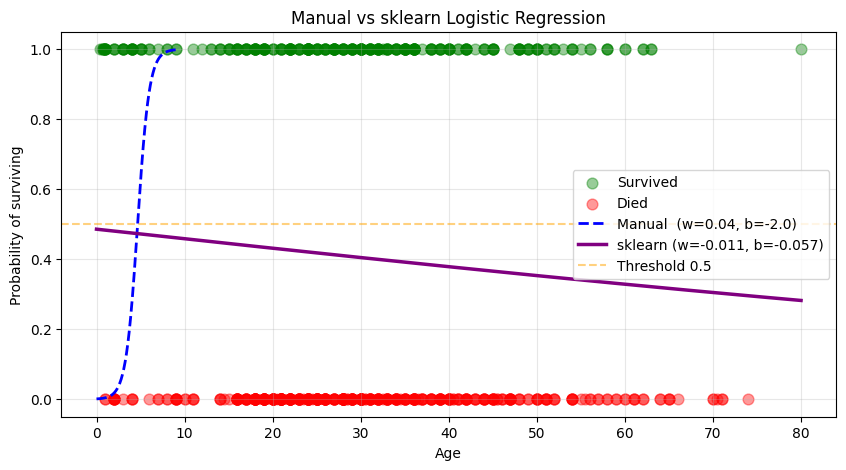

In [ ]:
X = x.reshape(-1, 1)

model = LogisticRegression()
model.fit(X, y)

sk_weight = model.coef_[0][0]
sk_bias   = model.intercept_[0]
sk_boundary = -sk_bias / sk_weight
accuracy  = model.score(X, y)

print(f"sklearn  to weight = {sk_weight:.4f}  |  bias = {sk_bias:.4f}")
print(f"Boundary to  Age = {sk_boundary:.1f}")
print(f"Accuracy to {accuracy*100:.1f}%")

x_curve2 = np.linspace(0, 80, 300)
z_curve2  = sk_weight * x_curve2 + sk_bias
p_curve2  = sigmoid(z_curve2)

plt.figure(figsize=(10, 5))
plt.scatter(x[y == 1], y[y == 1], color="green", label="Survived", alpha=0.4, s=60)
plt.scatter(x[y == 0], y[y == 0], color="red",   label="Died",     alpha=0.4, s=60)
plt.plot(x_curve,  p_curve,  color="blue",   linewidth=2,   linestyle="--", label=f"Manual  (w={weight}, b={bias})")
plt.plot(x_curve2, p_curve2, color="purple", linewidth=2.5, label=f"sklearn (w={sk_weight:.3f}, b={sk_bias:.3f})")
plt.axhline(0.5, linestyle="--", color="orange", alpha=0.5, label="Threshold 0.5")
plt.xlabel("Age")
plt.ylabel("Probability of surviving")
plt.title("Manual vs sklearn Logistic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()